In [ ]:
!pip install tensorflow matplotlib opencv-python-headless kaggle -q

In [ ]:
from google.colab import files

print("Upload your kaggle.json file:")
uploaded = files.upload()

import os
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
os.rename("kaggle.json", os.path.expanduser("~/.kaggle/kaggle.json"))
os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
print("✅ Kaggle API ready")

Upload your kaggle.json file:


Saving kaggle.json to kaggle.json
✅ Kaggle API ready


In [ ]:
print("Downloading PlantVillage (leaf images)...")
!kaggle datasets download -d emmarex/plantdisease -p /content/plantvillage --unzip -q
print("✅ PlantVillage downloaded")

print("Downloading ImageNet mini (not_leaf images)...")
!kaggle datasets download -d ifigotin/imagenetmini-1000 -p /content/imagenet --unzip -q
print("✅ ImageNet mini downloaded")

# Check what was downloaded
print("\nPlantVillage folder:")
!ls /content/plantvillage

print("\nImageNet folder:")
!ls /content/imagenet

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
✅ PlantVillage downloaded
Dataset URL: https://www.kaggle.com/datasets/ifigotin/imagenetmini-1000
License(s): unknown
✅ ImageNet mini downloaded

PlantVillage folder:
plantvillage  PlantVillage

ImageNet folder:
imagenet-mini


In [ ]:
import shutil
import random
from pathlib import Path

DATASET_DIR = "/content/dataset"
LEAF_DIR    = f"{DATASET_DIR}/leaf"
NOTLEAF_DIR = f"{DATASET_DIR}/not_leaf"

os.makedirs(LEAF_DIR,    exist_ok=True)
os.makedirs(NOTLEAF_DIR, exist_ok=True)

# ── Collect leaf images ─────────────────────────────────────────
print("Collecting leaf images...")

all_leaf = []
for ext in ["*.jpg", "*.JPG", "*.jpeg", "*.png", "*.PNG"]:
    all_leaf.extend(Path("/content/plantvillage").rglob(ext))

random.shuffle(all_leaf)
leaf_samples = all_leaf[:3000]

for i, src in enumerate(leaf_samples):
    dst = f"{LEAF_DIR}/leaf_{i:05d}.jpg"
    shutil.copy(str(src), dst)

print(f"✅ {len(leaf_samples)} leaf images copied")

# ── Collect not_leaf images ─────────────────────────────────────
print("Collecting not_leaf images...")

all_notleaf = []
for ext in ["*.jpg", "*.JPG", "*.jpeg", "*.png", "*.PNG"]:
    all_notleaf.extend(Path("/content/imagenet").rglob(ext))

random.shuffle(all_notleaf)
notleaf_samples = all_notleaf[:3000]

for i, src in enumerate(notleaf_samples):
    dst = f"{NOTLEAF_DIR}/notleaf_{i:05d}.jpg"
    shutil.copy(str(src), dst)

print(f"✅ {len(notleaf_samples)} not_leaf images copied")
print(f"\n📊 Dataset:")
print(f"   Leaf:     {len(os.listdir(LEAF_DIR))}")
print(f"   Not leaf: {len(os.listdir(NOTLEAF_DIR))}")

✅ 3000 leaf images copied
✅ 0 not_leaf images copied

📊 Dataset:
   Leaf:     3000
   Not leaf: 0


In [ ]:
# ─── CELL FIX — Rebuild not_leaf with correct extension ───
import shutil, random, os
from pathlib import Path

NOTLEAF_DIR = "/content/dataset/not_leaf"
os.makedirs(NOTLEAF_DIR, exist_ok=True)

# Clear existing empty folder
for f in Path(NOTLEAF_DIR).glob("*"):
    f.unlink()

imagenet_root = "/content/imagenet/imagenet-mini/train"

# ── Find all JPEG files (uppercase extension) ──────────────
all_notleaf = []
for ext in ["*.JPEG", "*.jpeg", "*.jpg", "*.JPG", "*.png", "*.PNG"]:
    found = list(Path(imagenet_root).rglob(ext))
    if found:
        print(f"{ext}: {len(found)} files")
    all_notleaf.extend(found)

print(f"\nTotal found: {len(all_notleaf)}")

# ── Copy 3000 samples ──────────────────────────────────────
random.shuffle(all_notleaf)
samples = all_notleaf[:3000]

skipped = 0
for i, src in enumerate(samples):
    dst = f"{NOTLEAF_DIR}/notleaf_{i:05d}.jpg"
    try:
        shutil.copy(str(src), dst)
    except Exception as e:
        skipped += 1

print(f"\n✅ Done!")
print(f"   Not_leaf: {len(os.listdir(NOTLEAF_DIR))}")
print(f"   Leaf:     {len(os.listdir('/content/dataset/leaf'))}")
print(f"   Skipped:  {skipped}")

*.JPEG: 34745 files

Total found: 34745

✅ Done!
   Not_leaf: 3000
   Leaf:     3000
   Skipped:  0


In [ ]:
import cv2
import numpy as np

def simulate_esp32(img):
    # 1. Resize to ESP32 resolution
    img = cv2.resize(img, (320, 240))

    # 2. JPEG compression artifacts
    quality = random.randint(40, 75)
    _, enc  = cv2.imencode('.jpg', img,
                           [cv2.IMWRITE_JPEG_QUALITY, quality])
    img = cv2.imdecode(enc, cv2.IMREAD_COLOR)

    # 3. Random blur
    if random.random() > 0.5:
        k   = random.choice([3, 5])
        img = cv2.GaussianBlur(img, (k, k), 0)

    # 4. Random noise
    if random.random() > 0.5:
        noise = np.random.normal(0, random.uniform(5, 20),
                                 img.shape).astype(np.float32)
        img   = np.clip(img.astype(np.float32) + noise,
                        0, 255).astype(np.uint8)

    # 5. Random brightness
    factor = random.uniform(0.5, 1.5)
    img    = np.clip(img.astype(np.float32) * factor,
                     0, 255).astype(np.uint8)

    return img

print("Applying ESP32 simulation...")

all_images = (
    list(Path(LEAF_DIR).glob("*.jpg")) +
    list(Path(NOTLEAF_DIR).glob("*.jpg"))
)

for i, p in enumerate(all_images):
    img = cv2.imread(str(p))
    if img is None:
        continue
    img = simulate_esp32(img)
    cv2.imwrite(str(p), img)
    if i % 500 == 0:
        print(f"  {i}/{len(all_images)} done")

print("✅ ESP32 simulation applied")

Applying ESP32 simulation...
  0/6000 done
  500/6000 done
  1000/6000 done
  1500/6000 done
  2000/6000 done
  2500/6000 done
  3000/6000 done
  3500/6000 done
  4000/6000 done
  4500/6000 done
  5000/6000 done
  5500/6000 done
✅ ESP32 simulation applied


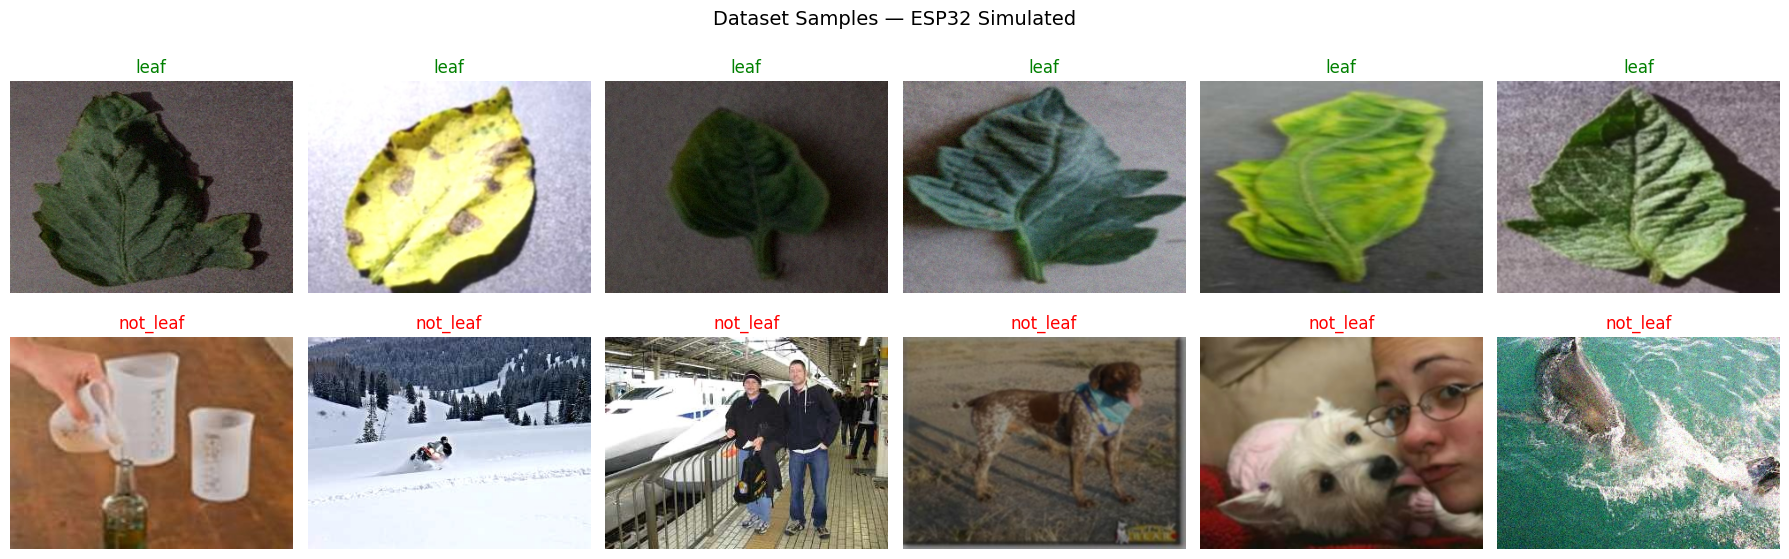

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
fig.suptitle("Dataset Samples — ESP32 Simulated", fontsize=14)

leaf_show    = random.sample(list(Path(LEAF_DIR).glob("*.jpg")),    6)
notleaf_show = random.sample(list(Path(NOTLEAF_DIR).glob("*.jpg")), 6)

for i, p in enumerate(leaf_show):
    img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
    axes[0][i].imshow(img)
    axes[0][i].set_title("leaf", color="green")
    axes[0][i].axis("off")

for i, p in enumerate(notleaf_show):
    img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
    axes[1][i].imshow(img)
    axes[1][i].set_title("not_leaf", color="red")
    axes[1][i].axis("off")

plt.tight_layout()
plt.savefig("/content/dataset_samples.png", dpi=100)
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE   = 64
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    zoom_range=0.3,
    brightness_range=[0.4, 1.6],
    horizontal_flip=True,
    vertical_flip=True,
    shear_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    DATASET_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training",
    shuffle=True
)

val_gen = datagen.flow_from_directory(
    DATASET_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    shuffle=False
)

print(f"📊 Class mapping: {train_gen.class_indices}")
print(f"   Training:   {train_gen.samples}")
print(f"   Validation: {val_gen.samples}")

# Save config
import json
config_data = {
    "leaf_class_index": train_gen.class_indices.get("leaf", 1),
    "class_indices":    train_gen.class_indices,
    "img_size":         IMG_SIZE
}
with open("/content/leaf_detector_config.json", "w") as f:
    json.dump(config_data, f, indent=2)

print("✅ Config saved")

Found 4800 images belonging to 2 classes.
Found 1200 images belonging to 2 classes.
📊 Class mapping: {'leaf': 0, 'not_leaf': 1}
   Training:   4800
   Validation: 1200
✅ Config saved


In [ ]:
from tensorflow.keras import layers, models

base = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)
base.trainable = False

model = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

model.summary()

/tmp/ipykernel_4879/1314179941.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 2, 2, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,435,393 (9.29 MB)

 Trainable params: 174,849 (683.00 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [ ]:
print("\n── Phase 1: Top layers only ──\n")

h1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=3,
            verbose=1
        )
    ]
)

print(f"\n✅ Phase 1 best val accuracy: {max(h1.history['val_accuracy']):.4f}")


── Phase 1: Top layers only ──

Epoch 1/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 55s 226ms/step - accuracy: 0.9098 - loss: 0.2212 - precision: 0.9069 - recall: 0.9133 - val_accuracy: 0.9625 - val_loss: 0.1127 - val_precision: 0.9727 - val_recall: 0.9517 - learning_rate: 0.0010
Epoch 2/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 18s 117ms/step - accuracy: 0.9500 - loss: 0.1376 - precision: 0.9534 - recall: 0.9463 - val_accuracy: 0.9675 - val_loss: 0.0934 - val_precision: 0.9762 - val_recall: 0.9583 - learning_rate: 0.0010
Epoch 3/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 17s 115ms/step - accuracy: 0.9590 - loss: 0.1160 - precision: 0.9599 - recall: 0.9579 - val_accuracy: 0.9675 - val_loss: 0.0934 - val_precision: 0.9795 - val_recall: 0.9550 - learning_rate: 0.0010
Epoch 4/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 18s 123ms/step - accuracy: 0.9523 - loss: 0.1346 - precision: 0.9529 - recall: 0.9517 - val_accuracy: 0.9675 - val_loss: 0.0836 - val_precision: 0.9667 - val_recall: 0.9683 - learning_rate: 0.0010
Epoch 5/20
150/150 

In [ ]:
print("\n── Phase 2: Fine-tuning ──\n")

base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

h2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.ModelCheckpoint(
            "/content/leaf_detector_best.h5",
            monitor="val_accuracy",
            save_best_only=True,
            verbose=1
        )
    ]
)

print(f"\n✅ Phase 2 best val accuracy: {max(h2.history['val_accuracy']):.4f}")


── Phase 2: Fine-tuning ──

Epoch 1/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.8689 - loss: 0.3324 - precision: 0.8666 - recall: 0.8776
Epoch 1: val_accuracy improved from None to 0.84833, saving model to /content/leaf_detector_best.h5



Epoch 1: finished saving model to /content/leaf_detector_best.h5
150/150 ━━━━━━━━━━━━━━━━━━━━ 46s 169ms/step - accuracy: 0.8831 - loss: 0.2949 - precision: 0.8755 - recall: 0.8933 - val_accuracy: 0.8483 - val_loss: 0.4353 - val_precision: 1.0000 - val_recall: 0.6967
Epoch 2/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.9124 - loss: 0.2213 - precision: 0.9179 - recall: 0.9079
Epoch 2: val_accuracy did not improve from 0.84833
150/150 ━━━━━━━━━━━━━━━━━━━━ 18s 117ms/step - accuracy: 0.9165 - loss: 0.2096 - precision: 0.9208 - recall: 0.9112 - val_accuracy: 0.8258 - val_loss: 0.5155 - val_precision: 0.9975 - val_recall: 0.6533
Epoch 3/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.9376 - loss: 0.1602 - precision: 0.9458 - recall: 0.9298
Epoch 3: val_accuracy improved from 0.84833 to 0.85583, saving model to /content/leaf_detector_best.h5



Epoch 3: finished saving model to /content/leaf_detector_best.h5
150/150 ━━━━━━━━━━━━━━━━━━━━ 19s 127ms/step - accuracy: 0.9354 - loss: 0.1696 - precision: 0.9398 - recall: 0.9304 - val_accuracy: 0.8558 - val_loss: 0.4450 - val_precision: 0.9977 - val_recall: 0.7133
Epoch 4/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.9354 - loss: 0.1896 - precision: 0.9366 - recall: 0.9328
Epoch 4: val_accuracy improved from 0.85583 to 0.86917, saving model to /content/leaf_detector_best.h5



Epoch 4: finished saving model to /content/leaf_detector_best.h5
150/150 ━━━━━━━━━━━━━━━━━━━━ 18s 117ms/step - accuracy: 0.9350 - loss: 0.1758 - precision: 0.9413 - recall: 0.9279 - val_accuracy: 0.8692 - val_loss: 0.3755 - val_precision: 0.9955 - val_recall: 0.7417
Epoch 5/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.9437 - loss: 0.1503 - precision: 0.9562 - recall: 0.9317
Epoch 5: val_accuracy improved from 0.86917 to 0.87917, saving model to /content/leaf_detector_best.h5



Epoch 5: finished saving model to /content/leaf_detector_best.h5
150/150 ━━━━━━━━━━━━━━━━━━━━ 19s 125ms/step - accuracy: 0.9427 - loss: 0.1465 - precision: 0.9489 - recall: 0.9358 - val_accuracy: 0.8792 - val_loss: 0.3679 - val_precision: 0.9956 - val_recall: 0.7617
Epoch 6/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.9418 - loss: 0.1499 - precision: 0.9420 - recall: 0.9405
Epoch 6: val_accuracy improved from 0.87917 to 0.90083, saving model to /content/leaf_detector_best.h5


...


Epoch 10: finished saving model to /content/leaf_detector_best.h5
150/150 ━━━━━━━━━━━━━━━━━━━━ 19s 125ms/step - accuracy: 0.9602 - loss: 0.1089 - precision: 0.9643 - recall: 0.9558 - val_accuracy: 0.9525 - val_loss: 0.1352 - val_precision: 0.9982 - val_recall: 0.9067
Epoch 11/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.9503 - loss: 0.1185 - precision: 0.9545 - recall: 0.9465
Epoch 11: val_accuracy improved from 0.95250 to 0.95750, saving model to /content/leaf_detector_best.h5



Epoch 11: finished saving model to /content/leaf_detector_best.h5
150/150 ━━━━━━━━━━━━━━━━━━━━ 18s 119ms/step - accuracy: 0.9550 - loss: 0.1132 - precision: 0.9581 - recall: 0.9517 - val_accuracy: 0.9575 - val_loss: 0.1250 - val_precision: 0.9928 - val_recall: 0.9217
Epoch 12/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.9629 - loss: 0.1009 - precision: 0.9628 - recall: 0.9624
Epoch 12: val_accuracy improved from 0.95750 to 0.95833, saving model to /content/leaf_detector_best.h5



Epoch 12: finished saving model to /content/leaf_detector_best.h5
150/150 ━━━━━━━━━━━━━━━━━━━━ 19s 126ms/step - accuracy: 0.9623 - loss: 0.1063 - precision: 0.9668 - recall: 0.9575 - val_accuracy: 0.9583 - val_loss: 0.1265 - val_precision: 0.9964 - val_recall: 0.9200
Epoch 13/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.9626 - loss: 0.1072 - precision: 0.9597 - recall: 0.9637
Epoch 13: val_accuracy improved from 0.95833 to 0.96667, saving model to /content/leaf_detector_best.h5



Epoch 13: finished saving model to /content/leaf_detector_best.h5
150/150 ━━━━━━━━━━━━━━━━━━━━ 18s 120ms/step - accuracy: 0.9679 - loss: 0.0933 - precision: 0.9679 - recall: 0.9679 - val_accuracy: 0.9667 - val_loss: 0.0939 - val_precision: 0.9844 - val_recall: 0.9483
Epoch 14/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.9608 - loss: 0.1077 - precision: 0.9597 - recall: 0.9617
Epoch 14: val_accuracy did not improve from 0.96667
150/150 ━━━━━━━━━━━━━━━━━━━━ 18s 117ms/step - accuracy: 0.9615 - loss: 0.1040 - precision: 0.9659 - recall: 0.9567 - val_accuracy: 0.9592 - val_loss: 0.1056 - val_precision: 0.9893 - val_recall: 0.9283
Epoch 15/15
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.9599 - loss: 0.1116 - precision: 0.9560 - recall: 0.9633
Epoch 15: val_accuracy improved from 0.96667 to 0.97500, saving model to /content/leaf_detector_best.h5



Epoch 15: finished saving model to /content/leaf_detector_best.h5
150/150 ━━━━━━━━━━━━━━━━━━━━ 19s 124ms/step - accuracy: 0.9631 - loss: 0.1043 - precision: 0.9645 - recall: 0.9617 - val_accuracy: 0.9750 - val_loss: 0.0818 - val_precision: 0.9863 - val_recall: 0.9633
Restoring model weights from the end of the best epoch: 15.

✅ Phase 2 best val accuracy: 0.9750


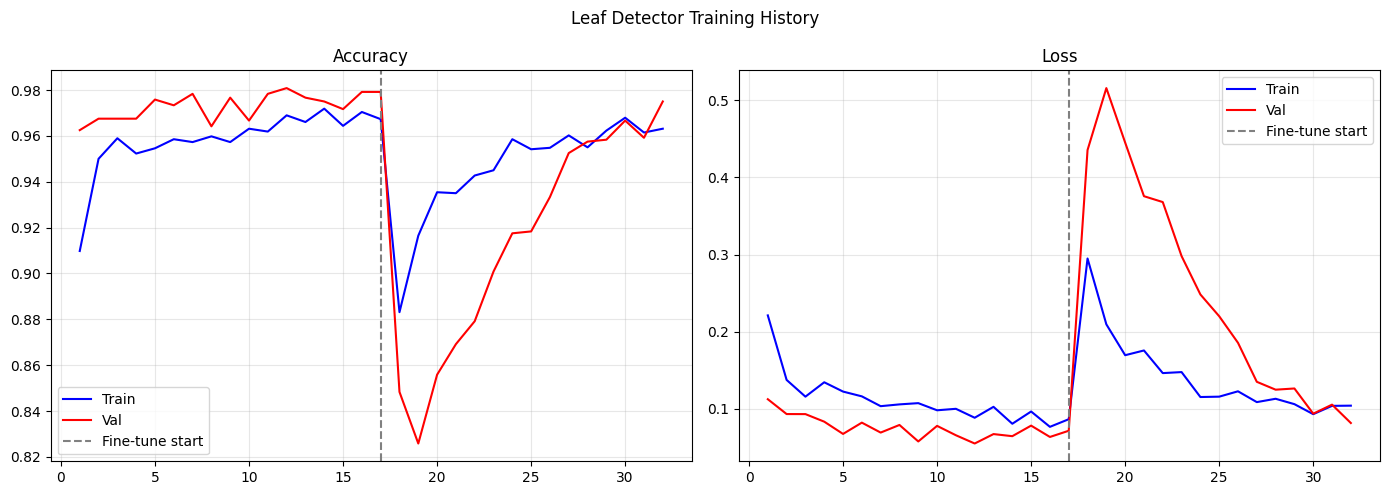

In [ ]:
acc      = h1.history["accuracy"]     + h2.history["accuracy"]
val_acc  = h1.history["val_accuracy"] + h2.history["val_accuracy"]
loss     = h1.history["loss"]         + h2.history["loss"]
val_loss = h1.history["val_loss"]     + h2.history["val_loss"]
epochs   = range(1, len(acc) + 1)
split    = len(h1.history["accuracy"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs, acc,     "b-",  label="Train")
ax1.plot(epochs, val_acc, "r-",  label="Val")
ax1.axvline(x=split, color="gray",
            linestyle="--", label="Fine-tune start")
ax1.set_title("Accuracy")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs, loss,     "b-", label="Train")
ax2.plot(epochs, val_loss, "r-", label="Val")
ax2.axvline(x=split, color="gray",
            linestyle="--", label="Fine-tune start")
ax2.set_title("Loss")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle("Leaf Detector Training History")
plt.tight_layout()
plt.savefig("/content/training_history.png", dpi=100)
plt.show()

38/38 ━━━━━━━━━━━━━━━━━━━━ 12s 180ms/step

📊 Classification Report:
              precision    recall  f1-score   support

    not_leaf       0.96      0.98      0.97       600
        leaf       0.98      0.95      0.97       600

    accuracy                           0.97      1200
   macro avg       0.97      0.97      0.97      1200
weighted avg       0.97      0.97      0.97      1200



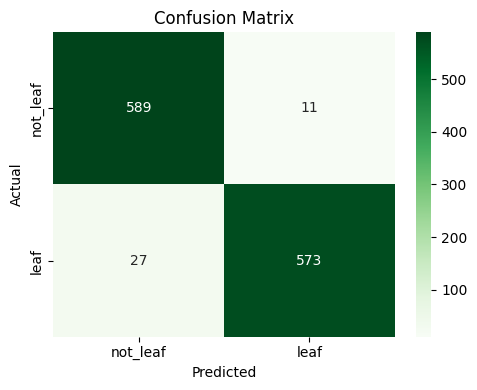

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

val_gen.reset()
y_prob = model.predict(val_gen, verbose=1)
y_pred = (y_prob > 0.5).astype(int).flatten()
y_true = val_gen.classes

print("\n📊 Classification Report:")
print(classification_report(
    y_true, y_pred,
    target_names=["not_leaf", "leaf"]
))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["not_leaf", "leaf"],
            yticklabels=["not_leaf", "leaf"])
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("/content/confusion_matrix.png", dpi=100)
plt.show()

In [ ]:
model.save("/content/leaf_detector.h5")
print("✅ Model saved")

# ── Download all files directly ─────────────────────────────────
print("\nDownloading files...")

files.download("/content/leaf_detector.h5")
files.download("/content/leaf_detector_config.json")
files.download("/content/training_history.png")
files.download("/content/confusion_matrix.png")

print("\n✅ Done! Add these to your Flask server folder:")
print("   → leaf_detector.h5")
print("   → leaf_detector_config.json")

✅ Model saved



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Done! Add these to your Flask server folder:
   → leaf_detector.h5
   → leaf_detector_config.json


In [ ]:
leaf_class_idx = train_gen.class_indices.get("leaf", 1)

def predict_leaf(img_path):
    img  = cv2.imread(str(img_path))
    img  = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img  = img / 255.0
    img  = np.expand_dims(img, axis=0)
    prob = model.predict(img, verbose=0)[0][0]

    if leaf_class_idx == 1:
        is_leaf = prob > 0.5
        conf    = float(prob)
    else:
        is_leaf = prob < 0.5
        conf    = float(1 - prob)

    return is_leaf, conf

leaf_test    = random.sample(list(Path(LEAF_DIR).glob("*.jpg")),    5)
notleaf_test = random.sample(list(Path(NOTLEAF_DIR).glob("*.jpg")), 5)

print("── Leaf images ──")
for p in leaf_test:
    result, conf = predict_leaf(p)
    icon = "✅" if result else "❌"
    print(f"  {icon} {'LEAF' if result else 'MISSED'}  {conf:.3f}")

print("\n── Not-leaf images ──")
for p in notleaf_test:
    result, conf = predict_leaf(p)
    icon = "✅" if not result else "❌"
    print(f"  {icon} {'CORRECT' if not result else 'FALSE POSITIVE'}  {conf:.3f}")

── Leaf images ──
  ✅ LEAF  1.000
  ✅ LEAF  0.999
  ✅ LEAF  0.998
  ✅ LEAF  1.000
  ✅ LEAF  1.000

── Not-leaf images ──
  ✅ CORRECT  0.348
  ✅ CORRECT  0.456
  ✅ CORRECT  0.000
  ✅ CORRECT  0.000
  ✅ CORRECT  0.000
